In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba as nb

In [10]:
#function to simulate the FH model
@nb.njit
def FH(params, N, N_steps, dt, ic = None, Z = None):

    #parameters of the model
    epsilon, psi, delta, nu, alpha, beta, gamma, mu, sigma = params

    #initial conditions
    if ic is None:
        x_0 = np.random.randn(N)
        y_0 = np.random.randn(N)
    else:
        #initial conditions
        x_0, y_0 = ic

    #quenched current
    if Z is None:
        Z = np.random.randn(N)

    #observable initialization
    X = np.zeros(N_steps)  
    Y = np.zeros(N_steps)

    #initialization of vectors
    x = np.zeros((N, N_steps))
    y = np.zeros((N, N_steps))

    #random initial conditions
    x[:, 0] = x_0
    y[:, 0] = y_0

    #temporal integration with eulero
    for t in range(1, N_steps):
        for n in nb.prange(N):
            X[t-1] = np.mean(x[:, t-1]) 
            Y[t-1] = np.mean(y[:, t-1])
            x[n, t] = x[n, t-1] + dt*(psi*x[n, t-1] + delta*(x[n, t-1])**3 + nu*y[n, t-1] + mu + sigma*Z[n] +epsilon*X[t-1])
            y[n, t] = y[n, t-1] + dt*alpha*(x[n, t-1] + beta*y[n, t-1]+gamma)
    X[N_steps-1] = np.mean(x[:, N_steps-1])
            
    return x, y, X, Y
def estimate_limit_cycle(x, y, phase_bins=1000, window_size=5):
    # Step 1: Compute the phase of each oscillator
    theta = np.arctan2(y, x)  # Phase in range [-π, π]
    
    # Step 2: Wrap phases into [0, 2π]
    theta = (theta + 2 * np.pi) % (2 * np.pi)
    
    # Step 3: Define phase grid
    phi_grid = np.linspace(0, 2 * np.pi, phase_bins, endpoint=False)

    # Step 4: Compute mean x and y per phase bin
    mean_x = np.zeros(phase_bins)
    mean_y = np.zeros(phase_bins)

    delta_theta = 2 * np.pi / phase_bins
    for i, phi in enumerate(phi_grid):
        mask = (theta >= phi) & (theta < phi + delta_theta)  # Select oscillators in bin
        if np.any(mask):  # Avoid empty bins
            mean_x[i] = np.mean(x[mask])
            mean_y[i] = np.mean(y[mask])
        else:
            mean_x[i] = np.nan
            mean_y[i] = np.nan

    mean_x = mean_x[mean_x != np.nan]
    mean_y = mean_y[mean_y != np.nan]

    return phi_grid, mean_x, mean_y


In [24]:
### FIXED PARAMETERS
psi = 1
delta = -1/3
nu = -1
alpha = 0.1
beta = -0.8
gamma = 0.7
mu = 0.6
sigma = 0.1

# epsilon values to simulate
eps_list = [0.0, 0.01, 0.03, 0.05, 0.1]

#simulation parameters
N = 1000
N_steps = 80_000
dt = 0.05

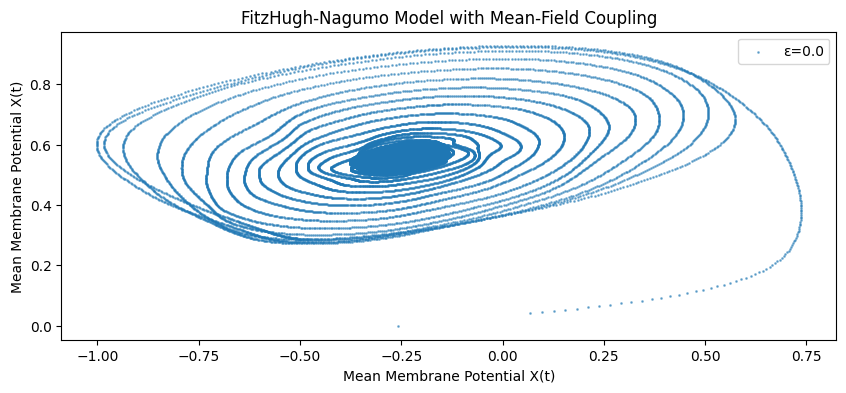

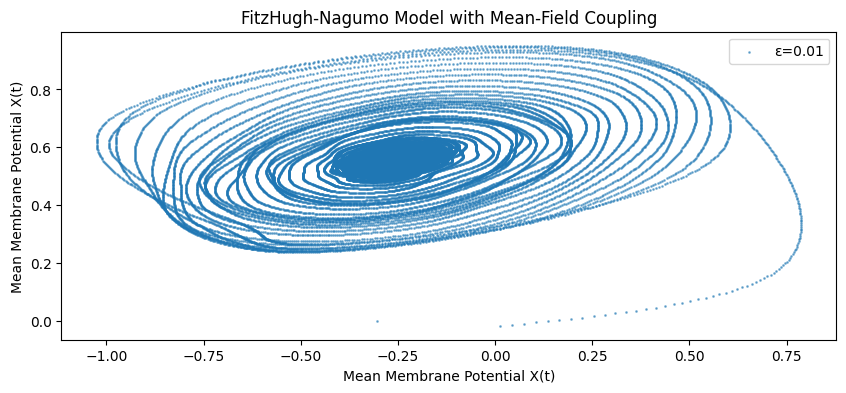

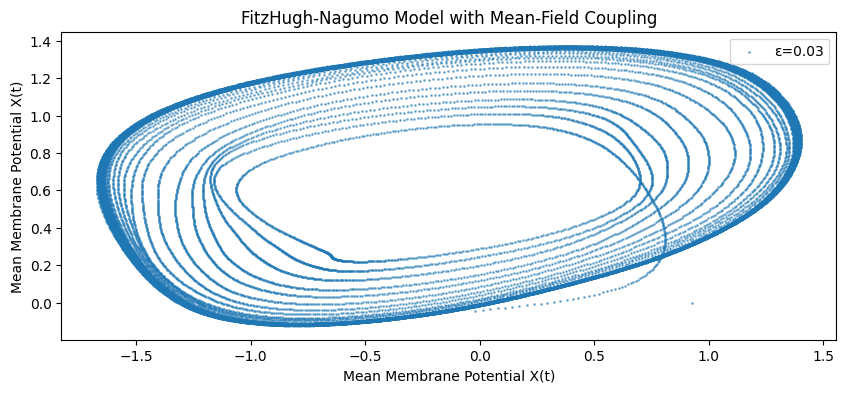

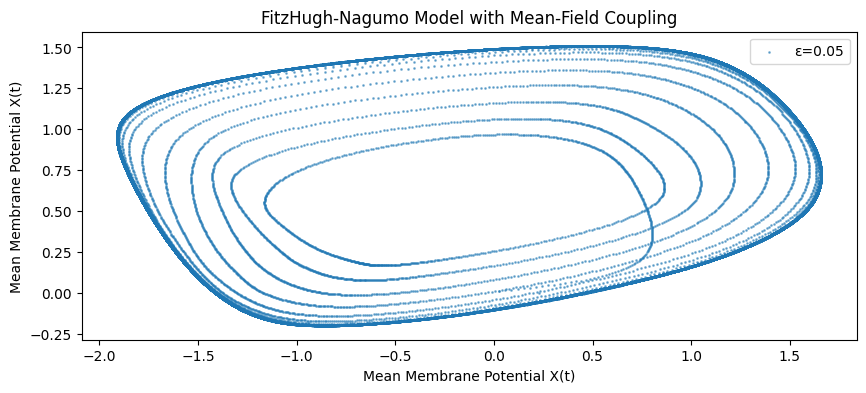

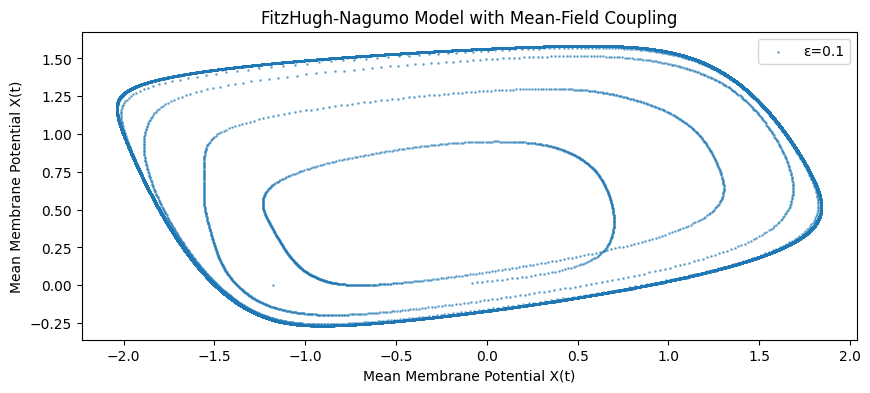

In [130]:
x_list = []
y_list = []
X_list = []
Y_list = []
for eps in eps_list:
    params = (eps, psi, delta, nu, alpha, beta, gamma, mu, sigma)
    x, y, X, Y = FH(params, N, N_steps, dt)

    np.savez(f'FH_mean_field_eps_{eps:.2f}.npz', x=x, y=y, X=X, Y=Y)

    x_list.append(x)
    y_list.append(y)
    X_list.append(X)
    Y_list.append(Y)

    plt.figure(figsize=(10, 4))
    plt.scatter(X, Y, s=1, alpha=0.5, label=f'ε={eps}')
    plt.xlabel('Mean Membrane Potential X(t)')
    plt.ylabel('Mean Membrane Potential X(t)')
    plt.title('FitzHugh-Nagumo Model with Mean-Field Coupling')
    plt.legend()
    plt.show()

In [ ]:
files = ['FH_mean_field_eps_0.30.npz',
 'FH_mean_field_eps_0.01.npz',
 'FH_mean_field_eps_0.03.npz',
 'FH_mean_field_eps_0.00.npz',
    'FH_mean_field_eps_0.05.npz',
    'FH_mean_field_eps_0.10.npz'
]

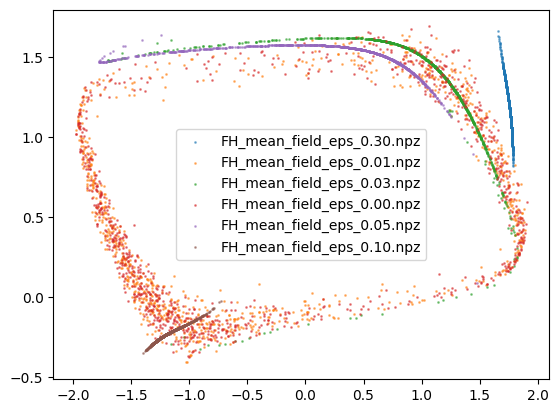

In [6]:
for file in files:
    data = np.load(file)
    x = data['x']
    y = data['y']
    
    plt.scatter(x[:, -1], y[:, -1], s=1, alpha=0.5, label = file)
plt.legend()

In [17]:
data = np.load('FH_mean_field_eps_0.10.npz')
x = data['x']
y = data['y']

phi_grid, lc_x, lc_y = estimate_limit_cycle(x, y)

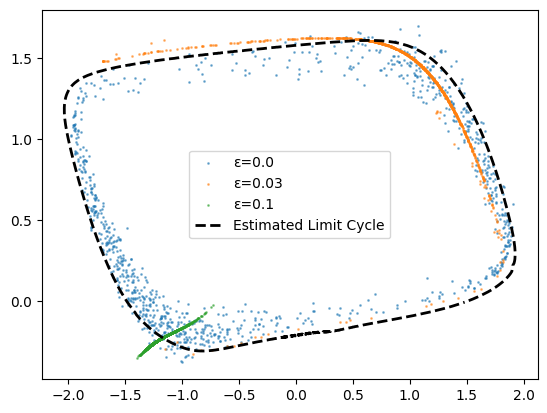

In [22]:
files_plot = ['FH_mean_field_eps_0.00.npz',
    'FH_mean_field_eps_0.03.npz',
     'FH_mean_field_eps_0.10.npz',]

eps_list = [0.0, 0.03, 0.1]

x_list = []
y_list = []
X_list = []
Y_list = []

for i, file in enumerate(files_plot):
    data = np.load(file)
    x = data['x']
    y = data['y']
    X = data['X']
    Y = data['Y']
    x_list.append(x)
    y_list.append(y)
    X_list.append(X)
    Y_list.append(Y)
    
    plt.scatter(x[:, -1], y[:, -1], s=1, alpha=0.5, label = f'ε={eps_list[i]}')

plt.plot(lc_x, lc_y, '--',color='black', linewidth=2, label='Estimated Limit Cycle')
plt.legend()

In [60]:
phi_grid, lc_x, lc_y = estimate_limit_cycle(x_list[2], y_list[2])

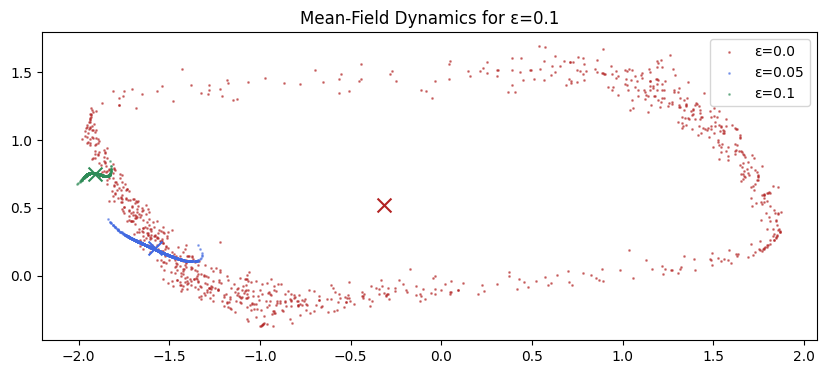

In [72]:
time = 2000

colors = ['firebrick', 'royalblue', 'seagreen', 'goldenrod']
plt.figure(figsize=(10, 4))
for i, eps in enumerate(eps_list[:3]):
    X = X_list[i][-time]
    Y = Y_list[i][-time]
    plt.scatter(x_list[i][:, -time], y_list[i][:, -time], label=f'ε={eps}', s=1, alpha=0.5, color=colors[i])
    plt.scatter(X, Y, color=colors[i], marker= 'x', s=100)

#plt.plot(lc_x, lc_y, '--', color='black', linewidth=2, label='Estimated Limit Cycle (ε=0.1)') 
plt.title(f'Mean-Field Dynamics for ε={eps}')
plt.legend()
plt.show()

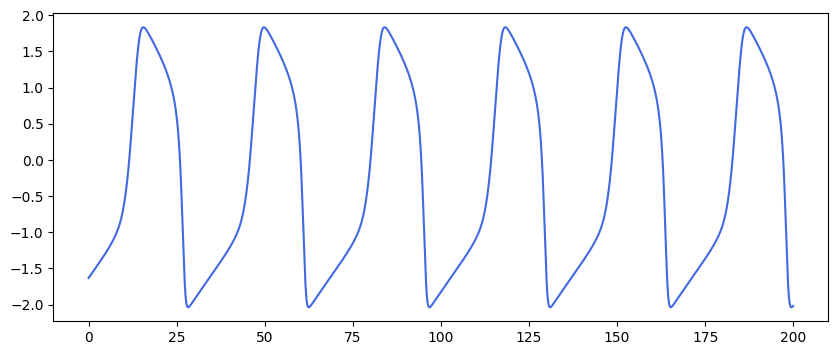

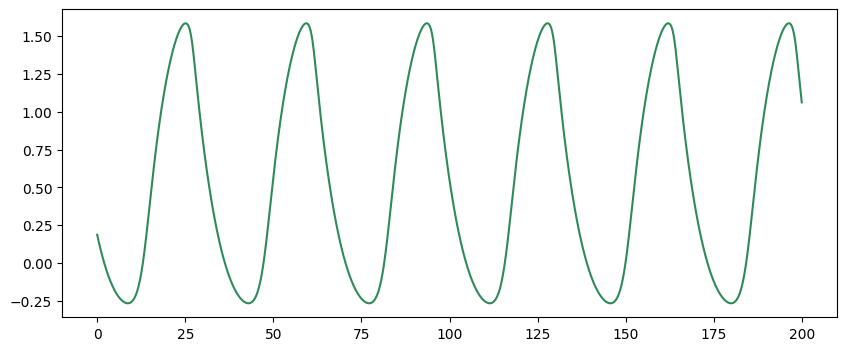

In [78]:
X = X_list[2][10000:14000]
Y = Y_list[2][10000:14000]

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(X))*dt, X, label='X(t)', color='royalblue')
plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(Y))*dt, Y, label='Y(t)', color='seagreen')

/tmp/ipykernel_135635/3385668526.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_phase.scatter(X, Y, color=colors[i], marker='x', s=80, edgecolor='black')


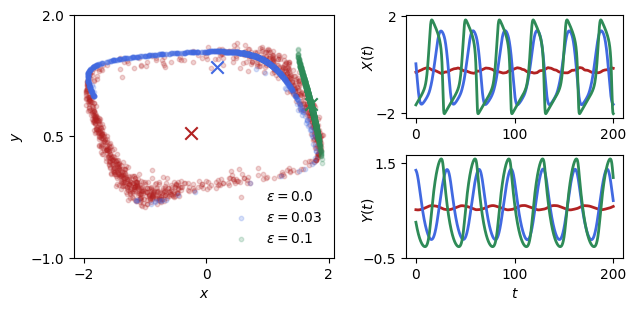

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

eps_list = [0.0, 0.03, 0.1]

time = 3200
colors = ['firebrick', 'royalblue', 'seagreen', 'goldenrod']

fig = plt.figure(figsize=(18/2.54, 8/2.54))
gs = GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1],
              wspace=0.3, hspace=0.35)

# ============================================================
# LEFT PANEL: Phase space (spans both rows)
# ============================================================
ax_phase = fig.add_subplot(gs[:, 0])

for i, eps in enumerate(eps_list[:3]):
    X = X_list[i][-time]
    Y = Y_list[i][-time]

    ax_phase.scatter(
        x_list[i][:, -time],
        y_list[i][:, -time],
        s=10,
        alpha=0.2,
        color=colors[i],
        label=rf'$\epsilon={eps}$'
    )

    #ax_phase.plot(X, Y, color=colors[i], linestyle='--', linewidth=2)
    ax_phase.scatter(X, Y, color=colors[i], marker='x', s=80, edgecolor='black')

ax_phase.set_xticks([-2, 0, 2])
ax_phase.set_yticks([-1, 0.5, 2])

ax_phase.set_xlabel(r'$x$')
ax_phase.set_ylabel(r'$y$')
#ax_phase.set_title('Mean-field dynamics')
ax_phase.legend(frameon=False, loc = 'lower right')

# ============================================================
# RIGHT TOP: X(t)
# ============================================================
ax_xt = fig.add_subplot(gs[0, 1])

X = X_list[2][10000:14000]
t = np.arange(len(X)) * dt

for i, eps in enumerate(eps_list[:3]):

    X = X_list[i][10000:14000]
    ax_xt.plot(t, X, color=colors[i], linewidth=2)

#ax_xt.set_ylabel(r'$X(t)$')
ax_xt.text(-40, 0.32, r'$X(t)$', rotation=90, va='center', ha='right')
ax_xt.set_xticks([0, 100, 200])
ax_xt.set_yticks([-2, 2])
#ax_xt.set_title(r'Time series ($\epsilon={}$)'.format(eps_list[2]))

# ============================================================
# RIGHT BOTTOM: Y(t)
# ============================================================
ax_yt = fig.add_subplot(gs[1, 1])

for i, eps in enumerate(eps_list[:3]):

    Y = Y_list[i][10000:14000]
    ax_yt.plot(t, Y, color=colors[i], linewidth=2)
ax_yt.set_xlabel(r'$t$')
#ax_yt.set_ylabel(r'$Y(t)$')
ax_yt.text(-40, 0.5, r'$Y(t)$', rotation=90, va='center', ha='right')
ax_yt.set_xticks([0, 100, 200])
ax_yt.set_yticks([-0.5, 1.5])

plt.show()


/tmp/ipykernel_135635/1156050185.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_phase.scatter(


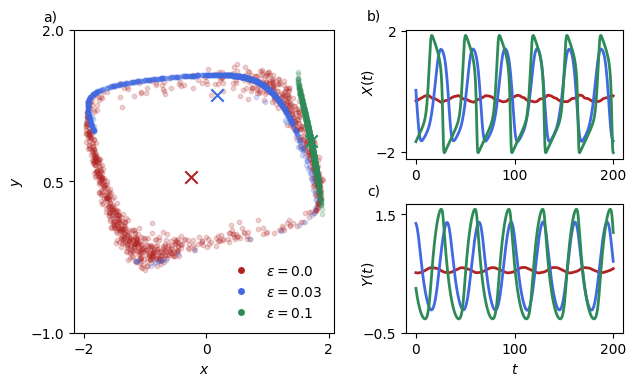

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

eps_list = [0.0, 0.03, 0.1]

time = 3200
colors = ['firebrick', 'royalblue', 'seagreen', 'goldenrod']

fig = plt.figure(figsize=(18/2.54, 10/2.54))
gs = GridSpec(
    2, 2,
    width_ratios=[1.2, 1],
    height_ratios=[1, 1],
    wspace=0.3,
    hspace=0.35
)

# ============================================================
# LEFT PANEL: Phase space (spans both rows)
# ============================================================
ax_phase = fig.add_subplot(gs[:, 0])

for i, eps in enumerate(eps_list[:3]):
    X = X_list[i][-time]
    Y = Y_list[i][-time]

    ax_phase.scatter(
        x_list[i][:, -time],
        y_list[i][:, -time],
        s=10,
        alpha=0.2,                 # keep transparency in plot
        color=colors[i],
        label=rf'$\epsilon={eps}$'
    )

    ax_phase.scatter(
        X, Y,
        color=colors[i],
        marker='x',
        s=80,
        edgecolor='black'
    )

ax_phase.set_xticks([-2, 0, 2])
ax_phase.set_yticks([-1, 0.5, 2])
ax_phase.set_xlabel(r'$x$')
ax_phase.set_ylabel(r'$y$')

# ----- custom legend (opaque colors) -----
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='none',
        markerfacecolor=colors[i],
        markeredgecolor='white',
        markersize=6,
        label=rf'$\epsilon={eps}$'
    )
    for i, eps in enumerate(eps_list[:3])
]

ax_phase.legend(
    handles=legend_handles,
    frameon=False,
    loc='lower right'
)

# Panel label a)
ax_phase.text(
    -0.12, 1.02, 'a)',
    transform=ax_phase.transAxes,
    fontsize=10,
    va='bottom'
)

# ============================================================
# RIGHT TOP: X(t)
# ============================================================
ax_xt = fig.add_subplot(gs[0, 1])

for i, eps in enumerate(eps_list[:3]):
    X = X_list[i][10000:14000]
    t = np.arange(len(X)) * dt
    ax_xt.plot(t, X, color=colors[i], linewidth=2)

ax_xt.text(-40, 0.32, r'$X(t)$', rotation=90, va='center', ha='right')
ax_xt.set_xticks([0, 100, 200])
ax_xt.set_yticks([-2, 2])

# Panel label b)
ax_xt.text(
    -0.18, 1.05, 'b)',
    transform=ax_xt.transAxes,
    fontsize=10,
    va='bottom'
)

# ============================================================
# RIGHT BOTTOM: Y(t)
# ============================================================
ax_yt = fig.add_subplot(gs[1, 1])

for i, eps in enumerate(eps_list[:3]):
    Y = Y_list[i][10000:14000]
    ax_yt.plot(t, Y, color=colors[i], linewidth=2)

ax_yt.set_xlabel(r'$t$')
ax_yt.text(-40, 0.5, r'$Y(t)$', rotation=90, va='center', ha='right')
ax_yt.set_xticks([0, 100, 200])
ax_yt.set_yticks([-0.5, 1.5])

# Panel label c)
ax_yt.text(
    -0.18, 1.05, 'c)',
    transform=ax_yt.transAxes,
    fontsize=10,
    va='bottom'
)

plt.savefig('placeholder.png', dpi=600)